<a href="https://colab.research.google.com/github/rupasahu/rupasahu/blob/main/Motion_Detection_Complete_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Motion Detection in CCTV
## Complete Pipeline:
1. Dataset Unzip
2. Frame Extraction
3. Data Preprocessing
4. Model Training (3 Models)
5. Evaluation (Accuracy, Precision, Recall, F1-Score)
6. Confusion Matrix
7. ROC Curve
8. Model Comparison Graph


In [1]:

import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from skimage.feature import hog

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1: Unzip Dataset

In [3]:
ZIP_PATH = "/content/drive/MyDrive/archive (2).zip"     # change if needed
EXTRACT_PATH = "/content/datasets"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


## Step 2: Frame Extraction from Videos

In [4]:

video_folder = "/content/datasets/Videos/Videos"
frame_folder = "/content/frames"

os.makedirs(frame_folder, exist_ok=True)

for category in os.listdir(video_folder):
    category_path = os.path.join(video_folder, category)
    save_path = os.path.join(frame_folder, category)
    os.makedirs(save_path, exist_ok=True)

    for video in os.listdir(category_path):
        cap = cv2.VideoCapture(os.path.join(category_path, video))
        count = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if count % 10 == 0:
                cv2.imwrite(os.path.join(save_path, f"{video}_{count}.jpg"), frame)

            count += 1

        cap.release()

print("Frame Extraction Completed!")


Frame Extraction Completed!


## Step 3: Load and Preprocess Frames

In [5]:

IMG_SIZE = 64
X, y = [], []

labels = sorted(os.listdir("frames"))
label_map = {label:i for i,label in enumerate(labels)}

for label in labels:
    folder = os.path.join("frames", label)
    for img_name in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, img_name))
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        X.append(img)
        y.append(label_map[label])

X = np.array(X)
y = np.array(y)

print("Dataset Shape:", X.shape)


Dataset Shape: (25732, 64, 64, 3)


In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


## Model 1: HOG + SVM

In [7]:

X_train_hog = []
X_test_hog = []

for img in X_train:
    gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)
    X_train_hog.append(hog(gray, pixels_per_cell=(8,8)))

for img in X_test:
    gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)
    X_test_hog.append(hog(gray, pixels_per_cell=(8,8)))

svm = SVC(kernel='linear')
svm.fit(X_train_hog, y_train)

y_pred_svm = svm.predict(X_test_hog)


## Model 2: Custom CNN

In [8]:

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

cnn = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(len(labels), activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy'])

cnn.fit(X_train, y_train_cat, epochs=5, batch_size=16)

y_pred_cnn = np.argmax(cnn.predict(X_test), axis=1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 71s 53ms/step - accuracy: 0.2946 - loss: 2.1084
Epoch 2/5
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 84s 55ms/step - accuracy: 0.7497 - loss: 0.7894
Epoch 3/5
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 74s 57ms/step - accuracy: 0.8540 - loss: 0.4232
Epoch 4/5
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 70s 54ms/step - accuracy: 0.8966 - loss: 0.3086
Epoch 5/5
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 82s 54ms/step - accuracy: 0.9210 - loss: 0.2352
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step


## Model 3: Hybrid CNN + SVM

In [9]:
feature_extractor = Model(inputs=cnn.layers[0].input,
                          outputs=cnn.layers[-2].output)

X_train_feat = feature_extractor.predict(X_train)
X_test_feat = feature_extractor.predict(X_test)

scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat = scaler.transform(X_test_feat)

hybrid = SVC(kernel='linear', probability=True)
hybrid.fit(X_train_feat, y_train)

y_pred_hybrid = hybrid.predict(X_test_feat)

644/644 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step


## Evaluation Metrics

In [10]:

def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n{name}")
    print("Accuracy:", acc*100)
    print("Precision:", prec*100)
    print("Recall:", rec*100)
    print("F1 Score:", f1*100)
    return acc

acc1 = evaluate("Traditional SVM", y_test, y_pred_svm)
acc2 = evaluate("CNN", y_test, y_pred_cnn)
acc3 = evaluate("Hybrid", y_test, y_pred_hybrid)



Traditional SVM
Accuracy: 83.1746648533126
Precision: 83.32612887887872
Recall: 83.1746648533126
F1 Score: 83.14241876959859

CNN
Accuracy: 87.93471925393433
Precision: 88.24829545256378
Recall: 87.93471925393433
F1 Score: 87.8510283306057

Hybrid
Accuracy: 91.665047600544
Precision: 91.66238895411766
Recall: 91.665047600544
F1 Score: 91.64538600178774


## Confusion Matrix (Hybrid Model)

## Model 1: HOG + SVM

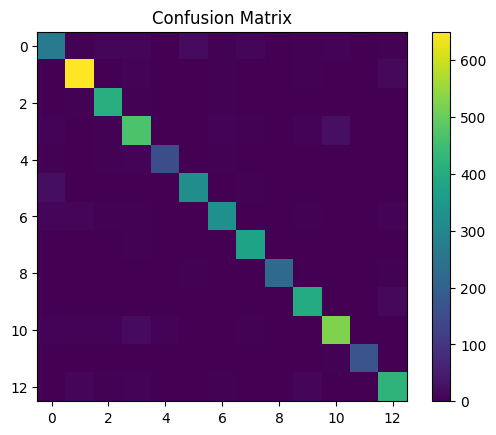

In [11]:

cm = confusion_matrix(y_test, y_pred_hybrid)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()


## ROC Curve (Hybrid Model)

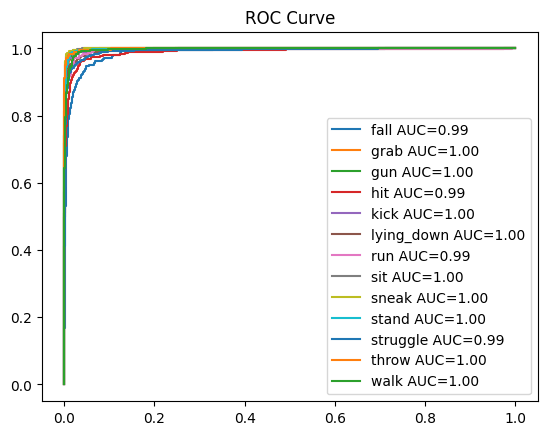

In [12]:

y_prob = hybrid.predict_proba(X_test_feat)

plt.figure()

for i in range(len(labels)):
    fpr, tpr, _ = roc_curve(y_test_cat[:,i], y_prob[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{labels[i]} AUC={roc_auc:.2f}")

plt.legend()
plt.title("ROC Curve")
plt.show()


## Model Comparison Graph

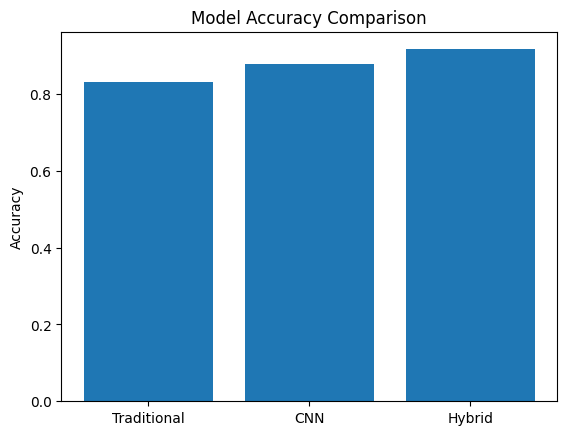

In [13]:

models = ['Traditional', 'CNN', 'Hybrid']
accuracies = [acc1, acc2, acc3]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


In [14]:
import joblib

# Save hybrid model
joblib.dump(hybrid, "hybrid_motion_model.h5")

print("Hybrid model saved successfully!")

Hybrid model saved successfully!


In [19]:
import joblib

# Save in current directory (not inside model folder)
joblib.dump(hybrid, "hybrid_motion_model.pkl")

print("Model saved successfully!")

Model saved successfully!
